# Lecture 04 — Apartment rent estimator

**Module:** OMC9000UK7 · Principles and Applications of Artificial Intelligence and Machine Learning  
**Programme:** MSc AI and Machine Learning · Gulf College  
**Lecture:** 04 — Introduction to Machine Learning and Data Mining  
**Topic:** Regression · **Learning outcome emphasis:** MLO1 and MLO3 (with MLO4 preparation through technique selection)

## Learning objective
Model nonlinear rental price patterns with a compact random forest.

## Practical problem
Predict monthly rent of imaginary apartments from area, bedrooms, age, location score and balcony.

## Dataset and transparency
The file **`dataset.csv`** was simulated for teaching. It is not collected from real people, businesses, medical systems or physical devices. Names/values are illustrative; models must not be deployed or used for real eligibility, employment, financial, clinical or safety decisions. A fixed random seed makes the example reproducible.

**How to run:** keep this notebook and `dataset.csv` in the same folder, then run all cells from top to bottom. If needed, install the packages listed in the collection’s `requirements.txt`.

**Assumptions:** Rents and location scores are fictional and should not be interpreted as market valuations.

## 1. Load the dataset and understand the variables
Always inspect several rows, column names, types, and possible missing values before choosing a model.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (7.2, 4.5), 'axes.grid': True, 'grid.alpha': .22})
DATA_FILE = Path('dataset.csv')
assert DATA_FILE.exists(), 'Place dataset.csv next to the notebook.'
df = pd.read_csv(DATA_FILE)
print(f'Dataset: {len(df):,} rows × {df.shape[1]} columns')
display(df.head())

Dataset: 740 rows × 6 columns


,floor_area_m2,bedrooms,building_age_years,location_score,has_balcony,monthly_rent_omr
0,177.8,3,2.9,6.9,0,766.5
1,65.7,1,25.1,6.0,0,256.4
2,164.0,2,21.9,7.8,0,735.7
3,191.3,5,0.1,3.6,1,852.9
4,215.6,5,11.6,3.8,0,822.1


In [2]:
print('Columns:', df.columns.tolist())
print('Missing values per column:')
print(df.isna().sum().to_string())

Columns: ['floor_area_m2', 'bedrooms', 'building_age_years', 'location_score', 'has_balcony', 'monthly_rent_omr']
Missing values per column:
floor_area_m2         0
bedrooms              0
building_age_years    0
location_score        0
has_balcony           0
monthly_rent_omr      0


## 2. Visualise the target and input–output relationship
For regression the output is **a number**. Study the scatterplot and target distribution before selecting a model.

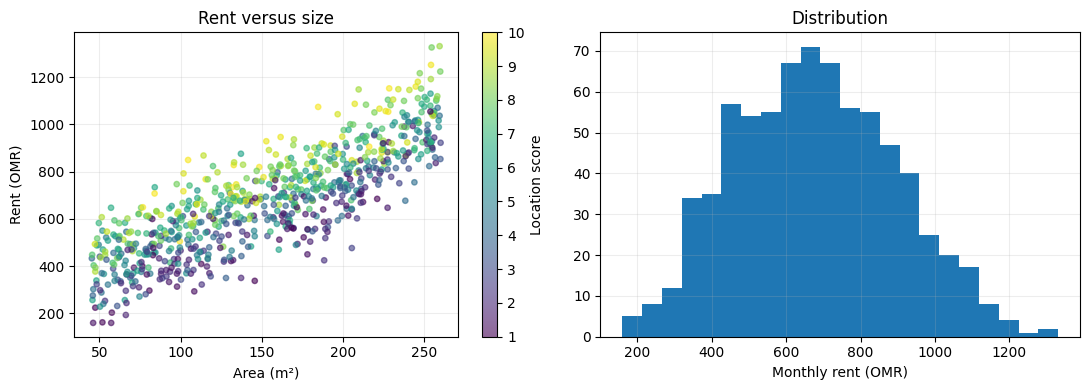

In [3]:
fig,ax=plt.subplots(1,2,figsize=(11,4))
sc=ax[0].scatter(df['floor_area_m2'],df['monthly_rent_omr'],c=df['location_score'],s=15,alpha=.6)
fig.colorbar(sc,ax=ax[0],label='Location score');ax[0].set(xlabel='Area (m²)',ylabel='Rent (OMR)',title='Rent versus size')
ax[1].hist(df['monthly_rent_omr'],bins=22);ax[1].set(xlabel='Monthly rent (OMR)',title='Distribution');plt.tight_layout();plt.show()

## 3. Split the data and fit the chosen regression model
Fit on training data only. The test set estimates how predictions may behave on new examples.

In [4]:
from sklearn.model_selection import train_test_split
X=df[['floor_area_m2', 'bedrooms', 'building_age_years', 'location_score', 'has_balcony']]
y=df['monthly_rent_omr']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.25,random_state=42)
print('Training rows:',len(X_train),'Test rows:',len(X_test))

Training rows: 555 Test rows: 185


### Algorithm choice
A **random forest regressor** combines multiple decision trees to model nonlinear relationships and interactions without requiring a straight line.

In [5]:
from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor(n_estimators=80,max_depth=9,min_samples_leaf=3,random_state=42,n_jobs=1)
model.fit(X_train,y_train)
print(pd.Series(model.feature_importances_,index=X.columns).sort_values(ascending=False))

floor_area_m2         0.664403
location_score        0.144673
bedrooms              0.126922
building_age_years    0.060617
has_balcony           0.003384
dtype: float64


## 4. Evaluate: MAE, RMSE and R²
**MAE** gives typical absolute error in the target’s units; **RMSE** penalises larger errors; **R²** compares prediction quality against predicting the mean. **Accuracy, precision, recall and a confusion matrix are not defined for continuous regression outputs** unless you introduce artificial categories, which would change the task.

MAE (OMR/month): 49.116
RMSE (OMR/month): 63.518
R²: 0.915


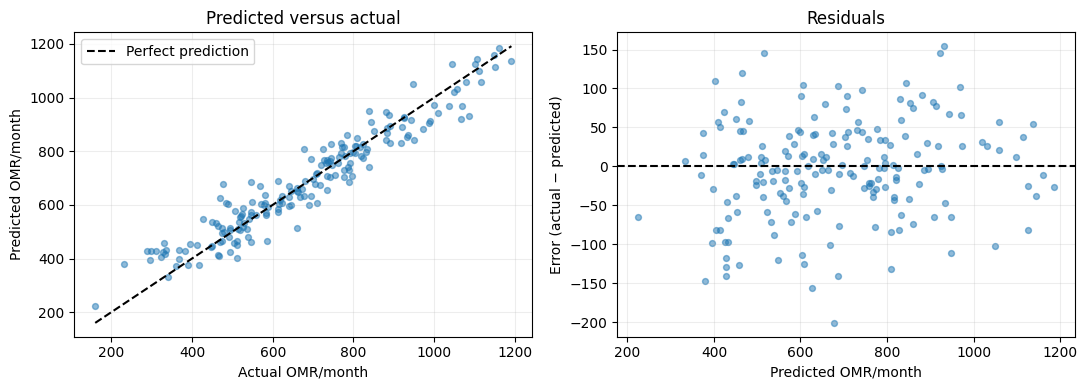

In [6]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
pred=model.predict(X_test)
print('MAE (OMR/month):',round(mean_absolute_error(y_test,pred),3))
print('RMSE (OMR/month):',round(np.sqrt(mean_squared_error(y_test,pred)),3))
print('R²:',round(r2_score(y_test,pred),3))
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].scatter(y_test,pred,alpha=.5,s=18)
limits=[min(y_test.min(),pred.min()),max(y_test.max(),pred.max())]
ax[0].plot(limits,limits,'k--',label='Perfect prediction');ax[0].legend()
ax[0].set(xlabel='Actual OMR/month',ylabel='Predicted OMR/month',title='Predicted versus actual')
ax[1].scatter(pred,y_test-pred,s=18,alpha=.5);ax[1].axhline(0,color='k',linestyle='--')
ax[1].set(xlabel='Predicted OMR/month',ylabel='Error (actual − predicted)',title='Residuals')
plt.tight_layout();plt.show()

## 5. Use the trained model on new inputs
Predictions are meaningful only within the data-generating range; extreme inputs involve extrapolation and are unreliable.

In [7]:
apartments=pd.DataFrame([{'floor_area_m2':90,'bedrooms':2,'building_age_years':10,'location_score':6,'has_balcony':0},{'floor_area_m2':185,'bedrooms':4,'building_age_years':2,'location_score':9,'has_balcony':1}])
apartments['estimated_rent_omr']=model.predict(apartments).round(1)
display(apartments)

,floor_area_m2,bedrooms,building_age_years,location_score,has_balcony,estimated_rent_omr
0,90,2,10,6,0,548.3
1,185,4,2,9,1,910.0


## Student investigation and discussion
1. Why might a straight line fail to model rental prices?
2. What are the limitations of interpreting random-forest importance causally?
3. How would you check whether some neighbourhoods are under-represented?

**Reflect:** What assumption makes this classroom dataset easier than the equivalent real-world problem?

## References and further learning
- Russell, S. J., & Norvig, P. (2021). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.
- Mitchell, T. M. (1997). *Machine Learning*. McGraw-Hill.
- scikit-learn User Guide: https://scikit-learn.org/stable/user_guide.html
- Course connection: Lecture 04, OMC9000UK7, supervised/unsupervised learning, modelling workflow and evaluation.